In [52]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sb 

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 
from xgboost import XGBClassifier 
from sklearn import metrics 

import warnings 
warnings.filterwarnings('ignore')


In [7]:
df = pd.read_csv("C:\\Users\\abhis\\Downloads\\archive\\TSLA.csv") 
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
1,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
2,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500
3,2010-07-07,3.280,3.326,2.996,3.160,3.160,34608500
4,2010-07-08,3.228,3.504,3.114,3.492,3.492,38557000


In [8]:
df.shape


(2843, 7)

In [9]:
df.describe()


,Open,High,Low,Close,Adj Close,Volume
count,2843.000000,2843.000000,2843.000000,2843.000000,2843.000000,2.843000e+03
mean,105.868475,108.031370,103.555733,105.924597,105.924597,3.141524e+07
std,188.738974,192.483055,184.638617,188.836358,188.836358,2.841880e+07
min,3.228000,3.326000,2.996000,3.160000,3.160000,5.925000e+05
25%,10.698000,11.026000,10.420000,10.727000,10.727000,1.251050e+07
50%,45.874001,46.493999,45.102001,45.916000,45.916000,2.481500e+07
75%,65.021000,66.251999,64.015001,65.275002,65.275002,4.012025e+07
max,891.380005,900.400024,871.599976,883.090027,883.090027,3.046940e+08


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2843 entries, 0 to 2842
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2843 non-null   object 
 1   Open       2843 non-null   float64
 2   High       2843 non-null   float64
 3   Low        2843 non-null   float64
 4   Close      2843 non-null   float64
 5   Adj Close  2843 non-null   float64
 6   Volume     2843 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 155.6+ KB


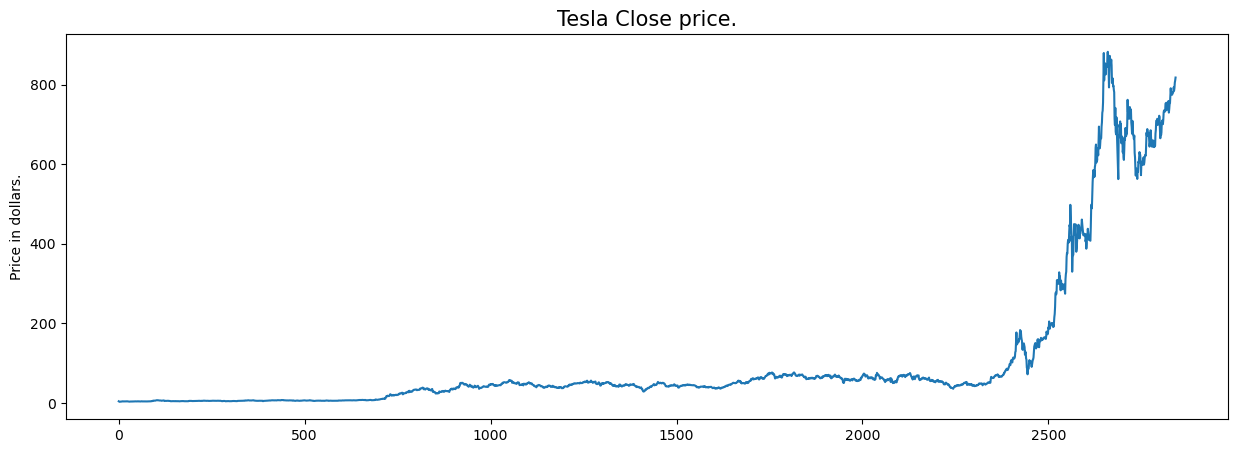

In [11]:
plt.figure(figsize=(15,5)) 
plt.plot(df['Close']) 
plt.title('Tesla Close price.', fontsize=15) 
plt.ylabel('Price in dollars.') 
plt.show()


In [12]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
1,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
2,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500
3,2010-07-07,3.280,3.326,2.996,3.160,3.160,34608500
4,2010-07-08,3.228,3.504,3.114,3.492,3.492,38557000


In [13]:
df[df['Close'] == df['Adj Close']].shape


(2843, 7)

In [14]:
df = df.drop(['Adj Close'], axis=1)


In [15]:
df.isnull().sum()


Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

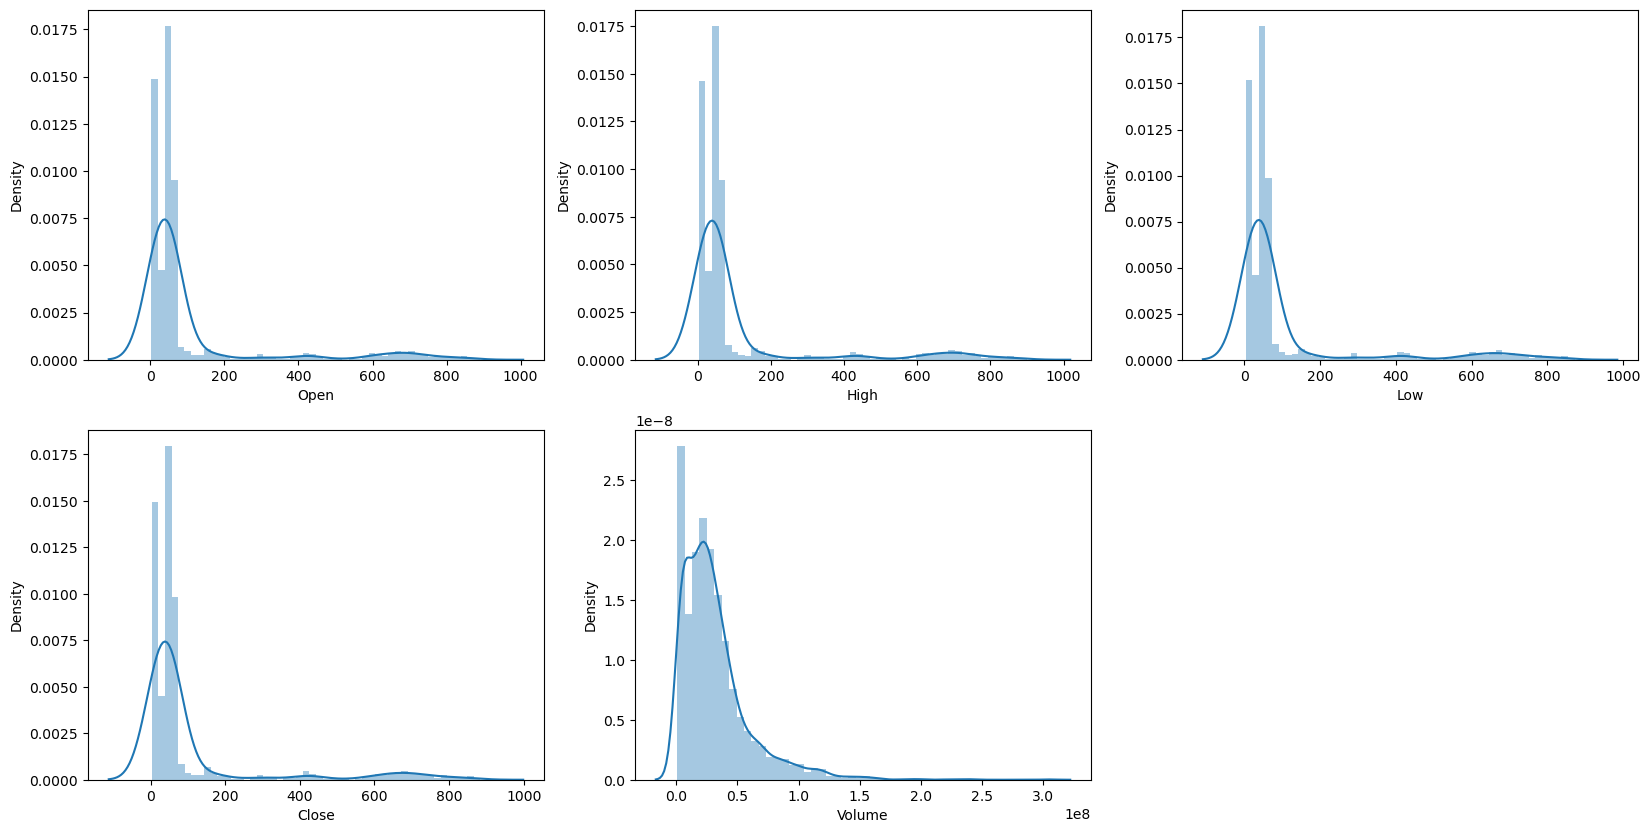

In [18]:
features = ['Open', 'High', 'Low', 'Close', 'Volume'] 

plt.subplots(figsize=(20,10)) 

for i, col in enumerate(features): 
    plt.subplot(2,3,i+1) 
    sb.distplot(df[col]) 
plt.show()


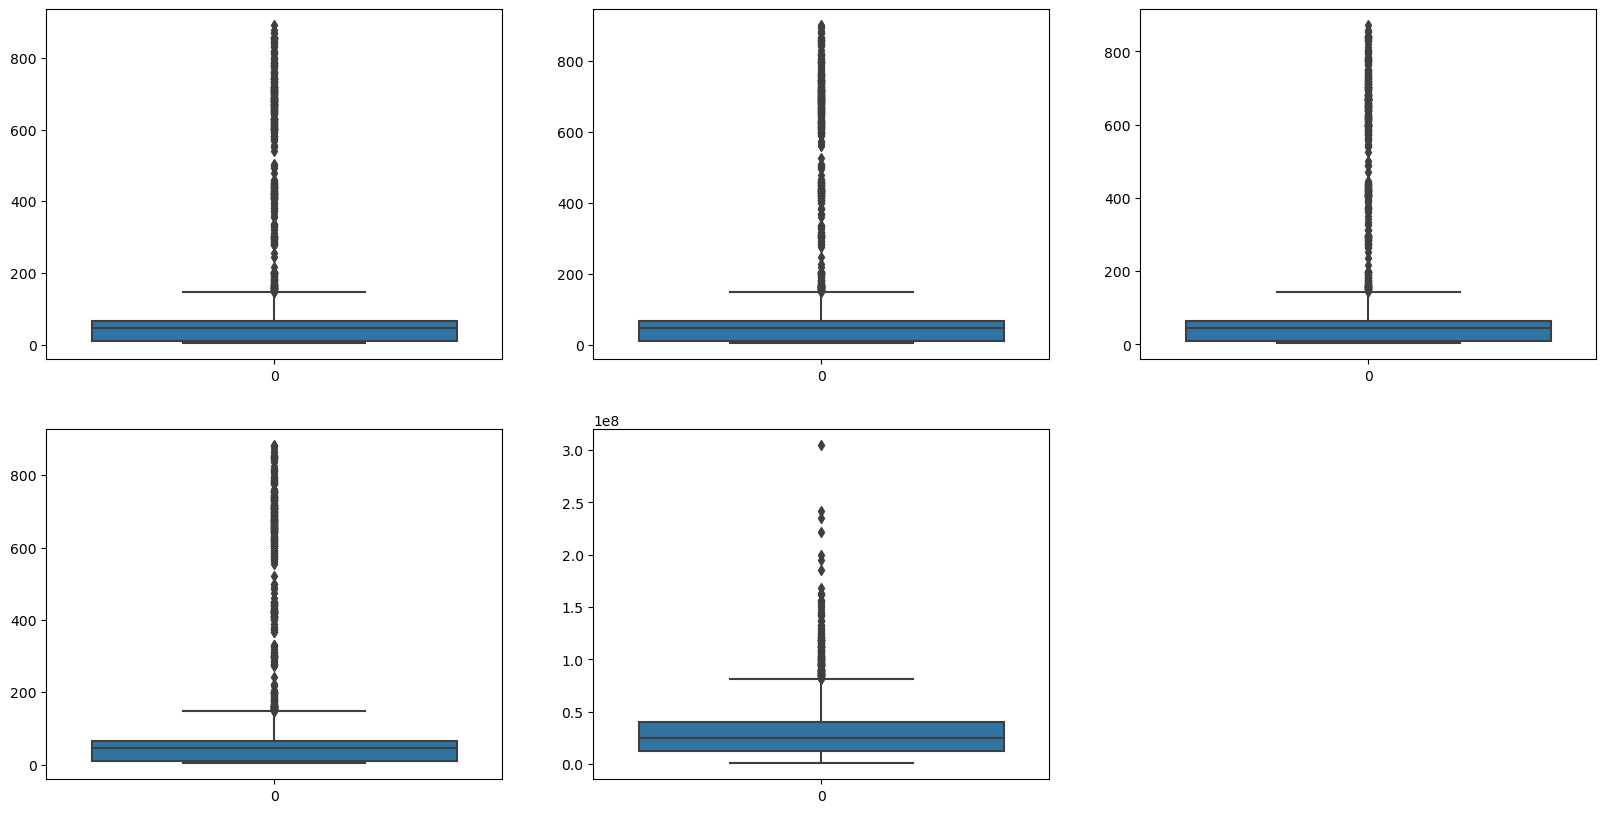

In [20]:
plt.subplots(figsize=(20,10)) 
for i, col in enumerate(features): 
    plt.subplot(2,3,i+1) 
    sb.boxplot(df[col]) 
plt.show()


In [26]:
splitted = df['Date'].str.split('-', expand=True) 

df['day'] = splitted[2].astype('int') 
df['month'] = splitted[1].astype('int') 
df['year'] = splitted[0].astype('int') 

df.head()


,Date,Open,High,Low,Close,Volume,day,month,year
0,2010-07-01,5.000,5.184,4.054,4.392,41094000,1,7,2010
1,2010-07-02,4.600,4.620,3.742,3.840,25699000,2,7,2010
2,2010-07-06,4.000,4.000,3.166,3.222,34334500,6,7,2010
3,2010-07-07,3.280,3.326,2.996,3.160,34608500,7,7,2010
4,2010-07-08,3.228,3.504,3.114,3.492,38557000,8,7,2010


In [27]:
df['is_quarter_end'] = np.where(df['month']%3==0,1,0) 
df.head()


,Date,Open,High,Low,Close,Volume,day,month,year,is_quarter_end
0,2010-07-01,5.000,5.184,4.054,4.392,41094000,1,7,2010,0
1,2010-07-02,4.600,4.620,3.742,3.840,25699000,2,7,2010,0
2,2010-07-06,4.000,4.000,3.166,3.222,34334500,6,7,2010,0
3,2010-07-07,3.280,3.326,2.996,3.160,34608500,7,7,2010,0
4,2010-07-08,3.228,3.504,3.114,3.492,38557000,8,7,2010,0


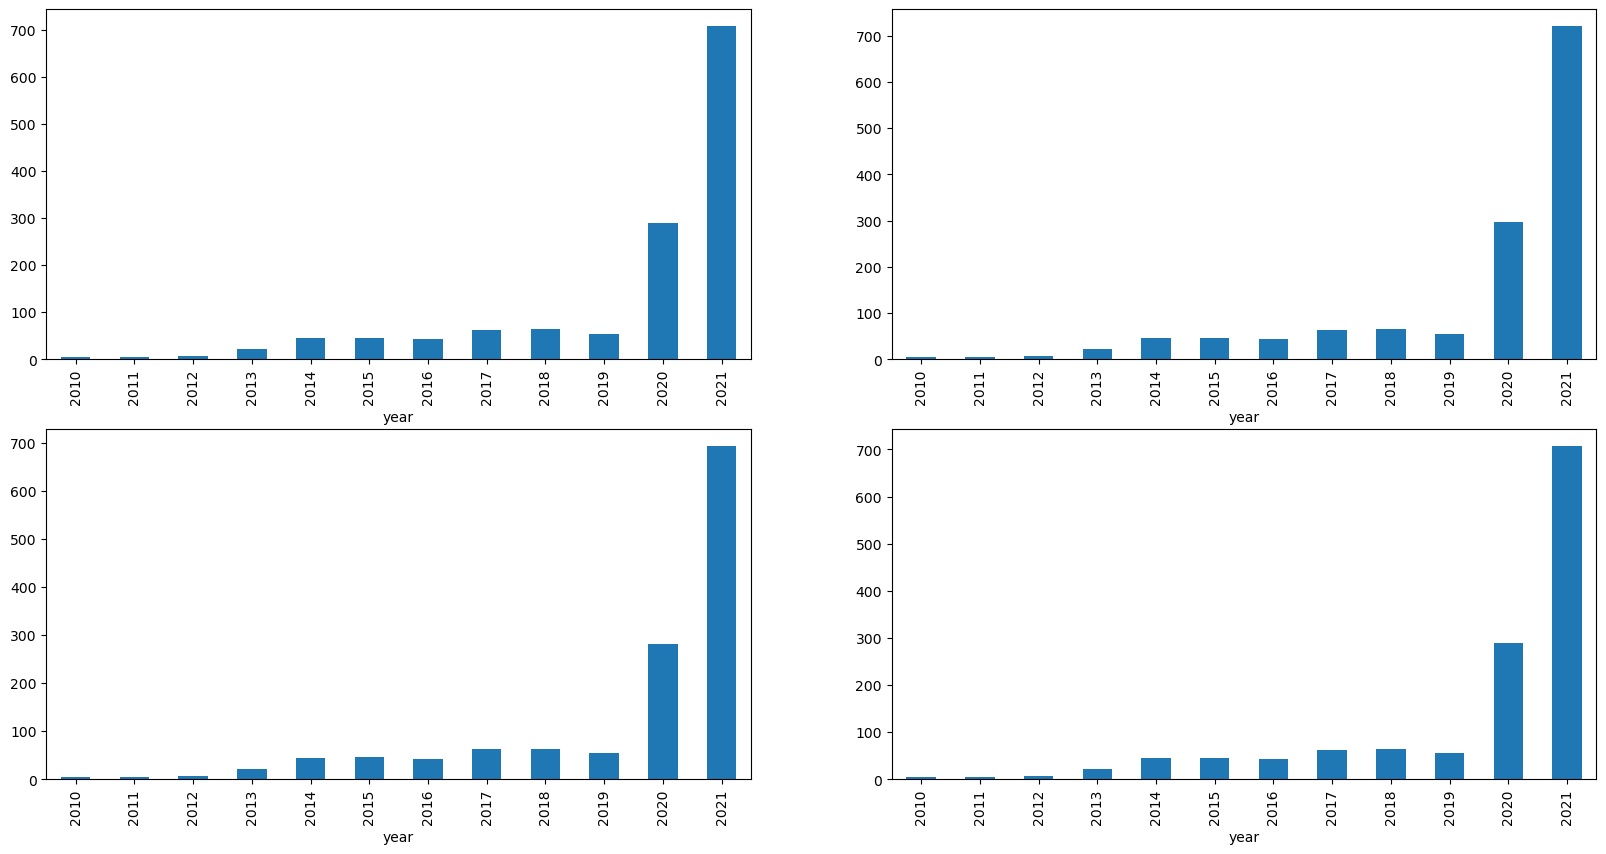

In [28]:
data_grouped = df.groupby('year').mean() 
plt.subplots(figsize=(20,10)) 

for i, col in enumerate(['Open', 'High', 'Low', 'Close']): 
    plt.subplot(2,2,i+1) 
    data_grouped[col].plot.bar() 
plt.show()


In [29]:
df.groupby('is_quarter_end').mean()


,Open,High,Low,Close,Volume,day,month,year
is_quarter_end,,,,,,,,
0,104.131372,106.218976,101.958846,104.152693,3.203170e+07,15.691332,6.143235,2015.642178
1,109.324414,111.637100,106.732715,109.449773,3.018880e+07,15.762355,7.473186,2015.629863


In [30]:
df['open-close'] = df['Open'] - df['Close'] 
df['low-high'] = df['Low'] - df['High'] 
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)


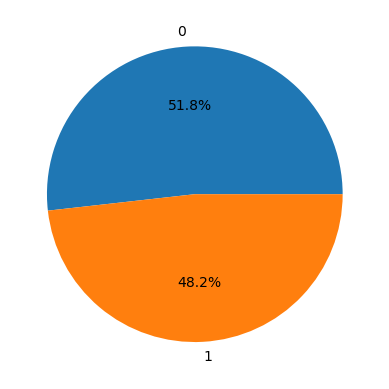

In [31]:
plt.pie(df['target'].value_counts().values, 
		labels=[0, 1], autopct='%1.1f%%') 
plt.show()


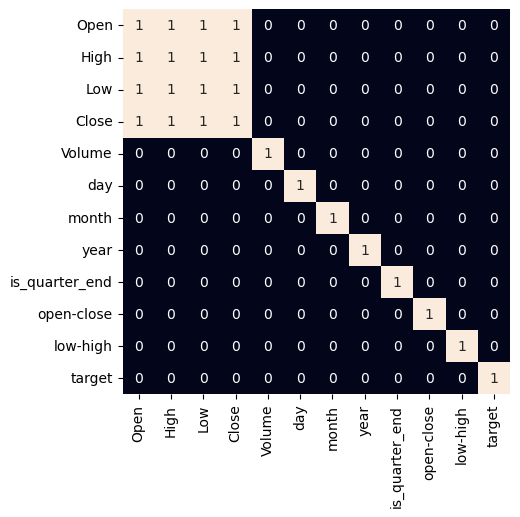

In [34]:
plt.figure(figsize=(5, 5)) 

# As our concern is with the highly 
# correlated features only so, we will visualize 
# our heatmap as per that criteria only. 
sb.heatmap(df.corr() > 0.9, annot=True, cbar=False) 
plt.show() 


In [35]:
features = df[['open-close', 'low-high', 'is_quarter_end']] 
target = df['target'] 

scaler = StandardScaler() 
features = scaler.fit_transform(features) 

X_train, X_valid, Y_train, Y_valid = train_test_split( 
	features, target, test_size=0.1, random_state=2022) 
print(X_train.shape, X_valid.shape) 


(2558, 3) (285, 3)


In [59]:
models = [LogisticRegression(), SVC(kernel='poly', probability=True), XGBClassifier()] 

for i in range(3):
    models[i].fit(X_train, Y_train) 

    print(f'{models[i]} : ') 
    print('Training Accuracy : ', metrics.roc_auc_score( 
        Y_train, models[i].predict_proba(X_train)[:,1])) 
    print('Validation Accuracy : ', metrics.roc_auc_score( 
        Y_valid, models[i].predict_proba(X_valid)[:,1])) 
    print()


LogisticRegression() : 
Training Accuracy :  0.5244953041945524
Validation Accuracy :  0.5346427161468614

SVC(kernel='poly', probability=True) : 
Training Accuracy :  0.5070227461204905
Validation Accuracy :  0.49269640742202914

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...) : 
Training